# Bar Inventory Forecasting and Inventory Recommendation System

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Inspection

In [2]:
df = pd.read_csv("../data/raw/bar_inventory_data.csv")

df.head()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [3]:
df.shape

(6575, 8)

In [4]:
df.columns

Index(['Date Time Served', 'Bar Name', 'Alcohol Type', 'Brand Name',
       'Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)',
       'Closing Balance (ml)'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date Time Served      6575 non-null   str    
 1   Bar Name              6575 non-null   str    
 2   Alcohol Type          6575 non-null   str    
 3   Brand Name            6575 non-null   str    
 4   Opening Balance (ml)  6575 non-null   float64
 5   Purchase (ml)         6575 non-null   float64
 6   Consumed (ml)         6575 non-null   float64
 7   Closing Balance (ml)  6575 non-null   float64
dtypes: float64(4), str(4)
memory usage: 411.1 KB


## 2. Data Cleaning and Validation

In [6]:
df["Date Time Served"] = pd.to_datetime(df["Date Time Served"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date Time Served      6575 non-null   datetime64[us]
 1   Bar Name              6575 non-null   str           
 2   Alcohol Type          6575 non-null   str           
 3   Brand Name            6575 non-null   str           
 4   Opening Balance (ml)  6575 non-null   float64       
 5   Purchase (ml)         6575 non-null   float64       
 6   Consumed (ml)         6575 non-null   float64       
 7   Closing Balance (ml)  6575 non-null   float64       
dtypes: datetime64[us](1), float64(4), str(3)
memory usage: 411.1 KB


In [7]:
print("Start date:", df["Date Time Served"].min())
print("End date:", df["Date Time Served"].max())

Start date: 2023-01-01 10:07:00
End date: 2024-01-01 22:46:00


In [8]:
df["Calculated Closing (ml)"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

df["Difference (ml)"] = (
    df["Closing Balance (ml)"]
    - df["Calculated Closing (ml)"]
)

df["Difference (ml)"].describe()

count    6575.000000
mean       -0.007925
std         0.469464
min        -9.250000
25%         0.000000
50%         0.000000
75%         0.000000
max         7.700000
Name: Difference (ml), dtype: float64

In [9]:
(df["Difference (ml)"].abs() > 0.01).sum()

np.int64(149)

In [10]:
df["Date"] = df["Date Time Served"].dt.date

df[["Date", "Bar Name", "Brand Name", "Consumed (ml)"]].head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Smith's Bar,Captain Morgan,0.0
1,2023-01-01,Smith's Bar,Yellow Tail,0.0
2,2023-01-01,Johnson's Bar,Grey Goose,0.0
3,2023-01-01,Johnson's Bar,Coors,0.0
4,2023-01-01,Johnson's Bar,Yellow Tail,0.0


## 3. Daily Consumption Analysis

In [11]:
daily_consumption = (
    df.groupby(["Date", "Bar Name", "Brand Name"])["Consumed (ml)"]
    .sum()
    .reset_index()
)

daily_consumption.head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Brown's Bar,Captain Morgan,0.0


In [12]:
daily_consumption.shape

(6575, 4)

In [13]:
daily_consumption["Bar Name"].nunique(), daily_consumption["Brand Name"].nunique()

(6, 16)

In [14]:
daily_consumption["Date"] = pd.to_datetime(daily_consumption["Date"])

print("Number of dates:", daily_consumption["Date"].nunique())
print("Expected days:", (daily_consumption["Date"].max() - daily_consumption["Date"].min()).days + 1)

Number of dates: 366
Expected days: 366


In [15]:
all_dates = pd.date_range(
    daily_consumption["Date"].min(),
    daily_consumption["Date"].max(),
    freq="D"
)

missing_dates = all_dates.difference(daily_consumption["Date"].unique())

print("Missing dates:", len(missing_dates))
print(missing_dates[:20])

Missing dates: 0
DatetimeIndex([], dtype='datetime64[s]', freq='D')


In [16]:
total_consumption = daily_consumption["Consumed (ml)"].sum()

print("Total consumption:", total_consumption, "ml")

Total consumption: 1968681.6600000001 ml


## 4. Exploratory Data Analysis

In [17]:
consumption_by_bar = (
    daily_consumption
    .groupby("Bar Name")["Consumed (ml)"]
    .sum()
    .sort_values(ascending=False)
)

consumption_by_bar

Bar Name
Johnson's Bar     344184.38
Anderson's Bar    335818.95
Smith's Bar       328713.91
Brown's Bar       326371.92
Thomas's Bar      318415.94
Taylor's Bar      315176.56
Name: Consumed (ml), dtype: float64

In [18]:
consumption_by_brand = (
    daily_consumption
    .groupby("Brand Name")["Consumed (ml)"]
    .sum()
    .sort_values(ascending=False)
)

consumption_by_brand

Brand Name
Grey Goose        158924.02
Jim Beam          139702.43
Captain Morgan    138035.53
Barefoot          132312.95
Yellow Tail       129843.65
Smirnoff          129176.67
Bacardi           127951.80
Malibu            127279.51
Jack Daniels      125050.89
Absolut           123659.02
Jameson           120001.14
Sutter Home       117245.66
Miller            107719.33
Coors              97999.32
Heineken           96967.09
Budweiser          96812.65
Name: Consumed (ml), dtype: float64

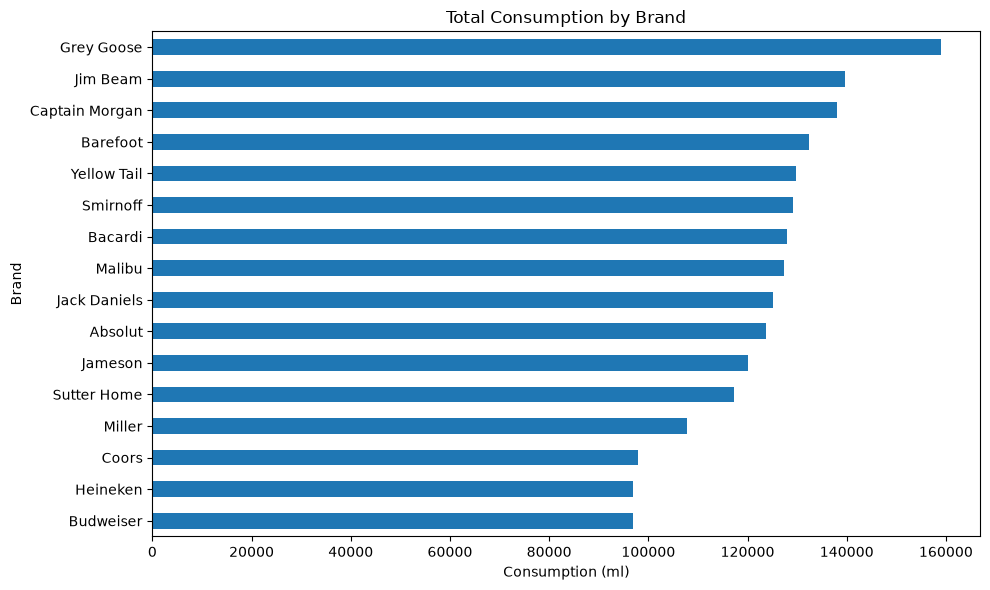

In [19]:
plt.figure(figsize=(10, 6))

consumption_by_brand.sort_values().plot(kind="barh")

plt.title("Total Consumption by Brand")
plt.xlabel("Consumption (ml)")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

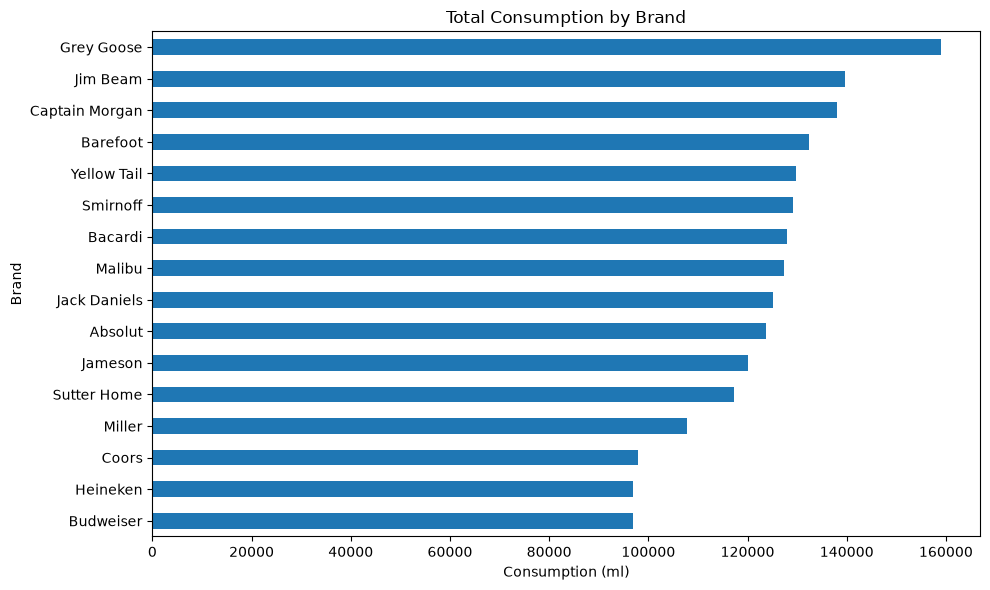

In [20]:
plt.figure(figsize=(10, 6))

consumption_by_brand.sort_values().plot(kind="barh")

plt.title("Total Consumption by Brand")
plt.xlabel("Consumption (ml)")
plt.ylabel("Brand")
plt.tight_layout()

plt.savefig("../report/consumption_by_brand.png", dpi=150)
plt.show()

In [21]:
abc = consumption_by_brand.to_frame(name="Total Consumption (ml)")

abc["Percentage"] = (
    abc["Total Consumption (ml)"]
    / abc["Total Consumption (ml)"].sum()
    * 100
)

abc["Cumulative Percentage"] = abc["Percentage"].cumsum()

abc["Category"] = np.where(
    abc["Cumulative Percentage"] <= 70,
    "A",
    np.where(
        abc["Cumulative Percentage"] <= 90,
        "B",
        "C"
    )
)

abc

,Total Consumption (ml),Percentage,Cumulative Percentage,Category
Brand Name,,,,
Grey Goose,158924.02,8.072611,8.072611,A
Jim Beam,139702.43,7.096243,15.168854,A
Captain Morgan,138035.53,7.011572,22.180426,A
Barefoot,132312.95,6.720891,28.901317,A
Yellow Tail,129843.65,6.595462,35.496779,A
Smirnoff,129176.67,6.561582,42.058362,A
Bacardi,127951.80,6.499365,48.557726,A
Malibu,127279.51,6.465215,55.022942,A
Jack Daniels,125050.89,6.352012,61.374953,A


In [22]:
abc["Category"].value_counts().sort_index()

Category
A    10
B     3
C     3
Name: count, dtype: int64

In [23]:
abc

,Total Consumption (ml),Percentage,Cumulative Percentage,Category
Brand Name,,,,
Grey Goose,158924.02,8.072611,8.072611,A
Jim Beam,139702.43,7.096243,15.168854,A
Captain Morgan,138035.53,7.011572,22.180426,A
Barefoot,132312.95,6.720891,28.901317,A
Yellow Tail,129843.65,6.595462,35.496779,A
Smirnoff,129176.67,6.561582,42.058362,A
Bacardi,127951.80,6.499365,48.557726,A
Malibu,127279.51,6.465215,55.022942,A
Jack Daniels,125050.89,6.352012,61.374953,A


In [24]:
daily_consumption.to_csv(
    "../data/processed/daily_bar_consumption.csv",
    index=False
)

print("Daily consumption data saved successfully.")

Daily consumption data saved successfully.


In [25]:
coverage = (
    daily_consumption
    .groupby(["Bar Name", "Brand Name"])["Date"]
    .nunique()
    .reset_index(name="Number of Days")
)

coverage["Number of Days"].describe()

count    96.000000
mean     68.489583
std      11.148750
min      40.000000
25%      60.000000
50%      69.500000
75%      76.000000
max      99.000000
Name: Number of Days, dtype: float64

In [26]:
coverage.sort_values("Number of Days").head(10)

,Bar Name,Brand Name,Number of Days
71,Taylor's Bar,Heineken,40
21,Brown's Bar,Coors,46
51,Smith's Bar,Budweiser,46
53,Smith's Bar,Coors,47
87,Thomas's Bar,Heineken,47
83,Thomas's Bar,Budweiser,48
3,Anderson's Bar,Budweiser,48
19,Brown's Bar,Budweiser,49
55,Smith's Bar,Heineken,50
35,Johnson's Bar,Budweiser,52


In [27]:
all_dates = pd.date_range(
    daily_consumption["Date"].min(),
    daily_consumption["Date"].max(),
    freq="D"
)

all_bars = daily_consumption["Bar Name"].unique()
all_brands = daily_consumption["Brand Name"].unique()

full_index = pd.MultiIndex.from_product(
    [all_dates, all_bars, all_brands],
    names=["Date", "Bar Name", "Brand Name"]
)

daily_complete = (
    daily_consumption
    .set_index(["Date", "Bar Name", "Brand Name"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

daily_complete.head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Anderson's Bar,Captain Morgan,0.0


In [28]:
daily_complete.shape

(35136, 4)

In [29]:
daily_complete = daily_complete.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

daily_complete.head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Absolut,0.00
1,2023-01-02,Anderson's Bar,Absolut,118.62
2,2023-01-03,Anderson's Bar,Absolut,0.00
3,2023-01-04,Anderson's Bar,Absolut,0.00
4,2023-01-05,Anderson's Bar,Absolut,463.20


## 5. Forecasting Feature Engineering

In [30]:
daily_complete["Lag_1"] = (
    daily_complete
    .groupby(["Bar Name", "Brand Name"])["Consumed (ml)"]
    .shift(1)
)

daily_complete["Lag_7"] = (
    daily_complete
    .groupby(["Bar Name", "Brand Name"])["Consumed (ml)"]
    .shift(7)
)

daily_complete["Lag_14"] = (
    daily_complete
    .groupby(["Bar Name", "Brand Name"])["Consumed (ml)"]
    .shift(14)
)

daily_complete.head(20)

,Date,Bar Name,Brand Name,Consumed (ml),Lag_1,Lag_7,Lag_14
0,2023-01-01,Anderson's Bar,Absolut,0.00,NaN,NaN,NaN
1,2023-01-02,Anderson's Bar,Absolut,118.62,0.00,NaN,NaN
2,2023-01-03,Anderson's Bar,Absolut,0.00,118.62,NaN,NaN
3,2023-01-04,Anderson's Bar,Absolut,0.00,0.00,NaN,NaN
4,2023-01-05,Anderson's Bar,Absolut,463.20,0.00,NaN,NaN
5,2023-01-06,Anderson's Bar,Absolut,453.02,463.20,NaN,NaN
6,2023-01-07,Anderson's Bar,Absolut,0.00,453.02,NaN,NaN
7,2023-01-08,Anderson's Bar,Absolut,275.08,0.00,0.00,NaN
8,2023-01-09,Anderson's Bar,Absolut,0.00,275.08,118.62,NaN
9,2023-01-10,Anderson's Bar,Absolut,0.00,0.00,0.00,NaN


In [31]:
daily_complete["Rolling_7"] = (
    daily_complete
    .groupby(["Bar Name", "Brand Name"])["Consumed (ml)"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

daily_complete.head(20)

,Date,Bar Name,Brand Name,Consumed (ml),Lag_1,Lag_7,Lag_14,Rolling_7
0,2023-01-01,Anderson's Bar,Absolut,0.00,NaN,NaN,NaN,NaN
1,2023-01-02,Anderson's Bar,Absolut,118.62,0.00,NaN,NaN,NaN
2,2023-01-03,Anderson's Bar,Absolut,0.00,118.62,NaN,NaN,NaN
3,2023-01-04,Anderson's Bar,Absolut,0.00,0.00,NaN,NaN,NaN
4,2023-01-05,Anderson's Bar,Absolut,463.20,0.00,NaN,NaN,NaN
5,2023-01-06,Anderson's Bar,Absolut,453.02,463.20,NaN,NaN,NaN
6,2023-01-07,Anderson's Bar,Absolut,0.00,453.02,NaN,NaN,NaN
7,2023-01-08,Anderson's Bar,Absolut,275.08,0.00,0.00,NaN,147.834286
8,2023-01-09,Anderson's Bar,Absolut,0.00,275.08,118.62,NaN,187.131429
9,2023-01-10,Anderson's Bar,Absolut,0.00,0.00,0.00,NaN,170.185714


In [32]:
daily_complete["Day_of_Week"] = daily_complete["Date"].dt.dayofweek

daily_complete[["Date", "Day_of_Week"]].head(10)

,Date,Day_of_Week
0,2023-01-01,6
1,2023-01-02,0
2,2023-01-03,1
3,2023-01-04,2
4,2023-01-05,3
5,2023-01-06,4
6,2023-01-07,5
7,2023-01-08,6
8,2023-01-09,0
9,2023-01-10,1


In [33]:
model_data = daily_complete.dropna().copy()

print("Rows available for modeling:", len(model_data))
model_data.head()

Rows available for modeling: 33792


,Date,Bar Name,Brand Name,Consumed (ml),Lag_1,Lag_7,Lag_14,Rolling_7,Day_of_Week
14,2023-01-15,Anderson's Bar,Absolut,0.0,0.0,275.08,0.00,39.297143,6
15,2023-01-16,Anderson's Bar,Absolut,0.0,0.0,0.00,118.62,0.000000,0
16,2023-01-17,Anderson's Bar,Absolut,0.0,0.0,0.00,0.00,0.000000,1
17,2023-01-18,Anderson's Bar,Absolut,0.0,0.0,0.00,0.00,0.000000,2
18,2023-01-19,Anderson's Bar,Absolut,0.0,0.0,0.00,463.20,0.000000,3


## 6. Demand Forecasting

In [34]:
cutoff_date = model_data["Date"].quantile(0.8)

train_data = model_data[model_data["Date"] < cutoff_date].copy()
test_data = model_data[model_data["Date"] >= cutoff_date].copy()

print("Cutoff date:", cutoff_date)
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Cutoff date: 2023-10-23 00:00:00
Training rows: 26976
Testing rows: 6816


In [35]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "Bar Name",
    "Brand Name",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_7",
    "Day_of_Week"
]

X = pd.get_dummies(
    model_data[features],
    columns=["Bar Name", "Brand Name"],
    dtype=int
)

y = model_data["Consumed (ml)"]

X_train = X.loc[train_data.index]
X_test = X.loc[test_data.index]

y_train = y.loc[train_data.index]
y_test = y.loc[test_data.index]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (26976, 27)
X_test shape: (6816, 27)


In [36]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [37]:
predictions = model.predict(X_test)

# Consumption cannot be negative
predictions = np.maximum(predictions, 0)

print("Predictions generated:", len(predictions))
print(predictions[:10])

Predictions generated: 6816
[ 39.0258875   49.12041714  85.14795595  94.94471389  59.31649024
 141.45433667  66.64389667  10.7846754   31.85847956  44.89698786]


## 7. Model Evaluation

In [38]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

wape = (
    np.sum(np.abs(y_test - predictions))
    / np.sum(np.abs(y_test))
    * 100
)

print(f"MAE: {mae:.2f} ml")
print(f"WAPE: {wape:.2f}%")

MAE: 98.42 ml
WAPE: 176.85%


In [39]:
baseline_predictions = test_data["Lag_7"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_wape = (
    np.sum(np.abs(y_test - baseline_predictions))
    / np.sum(np.abs(y_test))
    * 100
)

print(f"Baseline MAE: {baseline_mae:.2f} ml")
print(f"Baseline WAPE: {baseline_wape:.2f}%")

Baseline MAE: 97.37 ml
Baseline WAPE: 174.98%


In [40]:
zero_consumption = (model_data["Consumed (ml)"] == 0).mean() * 100

print(f"Zero-consumption records: {zero_consumption:.2f}%")

Zero-consumption records: 83.98%


In [41]:
non_zero_data = model_data[model_data["Consumed (ml)"] > 0]

print("Total records:", len(model_data))
print("Non-zero consumption records:", len(non_zero_data))
print(
    "Percentage of records with consumption:",
    f"{len(non_zero_data) / len(model_data) * 100:.2f}%"
)

Total records: 33792
Non-zero consumption records: 5414
Percentage of records with consumption: 16.02%


In [42]:
non_zero_test = y_test > 0

mae_non_zero = mean_absolute_error(
    y_test[non_zero_test],
    predictions[non_zero_test]
)

print(f"MAE on consumption days: {mae_non_zero:.2f} ml")
print(f"Number of consumption days in test set: {non_zero_test.sum()}")

MAE on consumption days: 281.97 ml
Number of consumption days in test set: 1087


In [43]:
baseline_non_zero_mae = mean_absolute_error(
    y_test[non_zero_test],
    baseline_predictions[non_zero_test]
)

print(f"Baseline MAE on consumption days: {baseline_non_zero_mae:.2f} ml")

Baseline MAE on consumption days: 320.37 ml


In [44]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,0.00,39.025887
1,174.39,49.120417
2,0.00,85.147956
3,0.00,94.944714
4,0.00,59.316490
5,0.00,141.454337
6,0.00,66.643897
7,0.00,10.784675
8,401.81,31.858480
9,0.00,44.896988


In [45]:
def simulate_inventory(group):
    inventory = group["Recommended Par Level (ml)"].iloc[0]
    pending_orders = []
    stockout_days = 0
    total_inventory = 0

    results = []

    for _, row in group.sort_values("Date").iterrows():
        received = sum(
            amount for arrival_date, amount in pending_orders
            if arrival_date <= row["Date"]
        )

        inventory += received

        pending_orders = [
            (arrival_date, amount)
            for arrival_date, amount in pending_orders
            if arrival_date > row["Date"]
        ]

        demand = row["Consumed (ml)"]
        inventory -= demand

        if inventory < 0:
            stockout_days += 1
            inventory = 0

        total_inventory += inventory

        par_level = row["Recommended Par Level (ml)"]
        order_quantity = max(par_level - inventory, 0)

        if order_quantity > 0:
            arrival_date = row["Date"] + pd.Timedelta(days=lead_time_days)
            pending_orders.append((arrival_date, order_quantity))

        results.append({
            "Date": row["Date"],
            "Bar Name": row["Bar Name"],
            "Brand Name": row["Brand Name"],
            "Inventory": inventory,
            "Demand": demand,
            "Order Quantity": order_quantity
        })

    result = pd.DataFrame(results)

    return result, stockout_days, total_inventory / len(group)

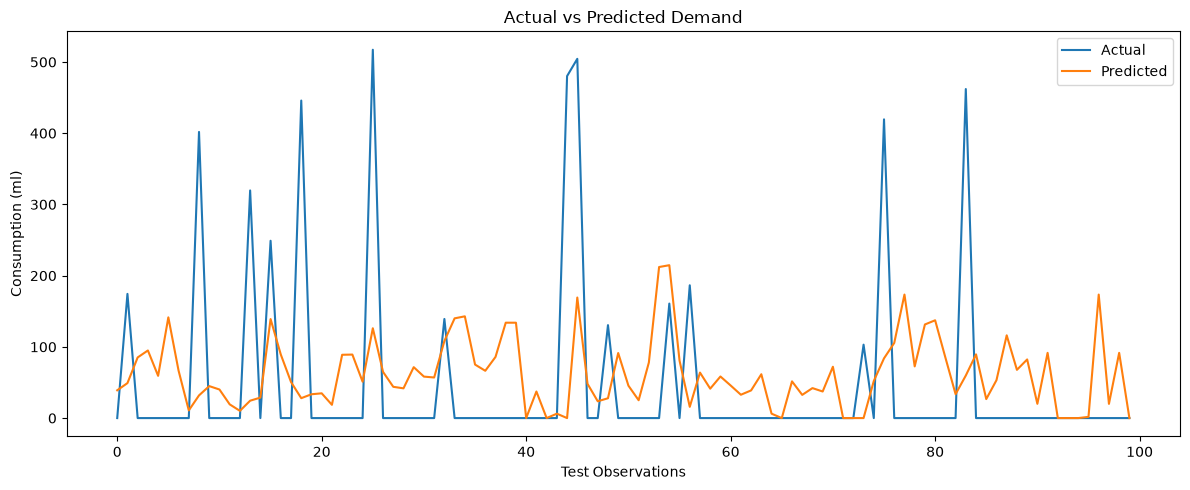

In [46]:
comparison_plot = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison_plot = comparison_plot.iloc[:100]

plt.figure(figsize=(12, 5))
plt.plot(comparison_plot["Actual"], label="Actual")
plt.plot(comparison_plot["Predicted"], label="Predicted")
plt.title("Actual vs Predicted Demand")
plt.xlabel("Test Observations")
plt.ylabel("Consumption (ml)")
plt.legend()
plt.tight_layout()

plt.savefig("../report/actual_vs_predicted.png", dpi=150)
plt.show()

In [47]:
bar_summary = (
    daily_consumption
    .groupby("Bar Name")["Consumed (ml)"]
    .sum()
    .reset_index()
    .sort_values("Consumed (ml)", ascending=False)
)

bar_summary

,Bar Name,Consumed (ml)
2,Johnson's Bar,344184.38
0,Anderson's Bar,335818.95
3,Smith's Bar,328713.91
1,Brown's Bar,326371.92
5,Thomas's Bar,318415.94
4,Taylor's Bar,315176.56


In [48]:
bar_summary.to_csv(
    "../data/processed/bar_consumption_summary.csv",
    index=False
)

print("Bar consumption summary saved.")

Bar consumption summary saved.


In [49]:
backtest_data = test_data.copy()

## 8. Inventory Recommendation

In [50]:
train_demand_stats = (
    train_data
    .groupby(["Bar Name", "Brand Name"])["Consumed (ml)"]
    .agg(["mean", "std"])
    .reset_index()
)

train_demand_stats.columns = [
    "Bar Name",
    "Brand Name",
    "Average Daily Demand (ml)",
    "Demand Std (ml)"
]

lead_time_days = 3
z_value = 1.645

train_demand_stats["Lead Time Demand (ml)"] = (
    train_demand_stats["Average Daily Demand (ml)"]
    * lead_time_days
)

train_demand_stats["Safety Stock (ml)"] = (
    z_value
    * train_demand_stats["Demand Std (ml)"]
    * np.sqrt(lead_time_days)
)

train_demand_stats["Recommended Par Level (ml)"] = (
    train_demand_stats["Lead Time Demand (ml)"]
    + train_demand_stats["Safety Stock (ml)"]
)

train_demand_stats.head()

,Bar Name,Brand Name,Average Daily Demand (ml),Demand Std (ml),Lead Time Demand (ml),Safety Stock (ml),Recommended Par Level (ml)
0,Anderson's Bar,Absolut,28.806192,92.823599,86.418577,264.475186,350.893762
1,Anderson's Bar,Bacardi,74.887260,163.543313,224.661779,465.971464,690.633244
2,Anderson's Bar,Barefoot,79.965658,166.711825,239.896975,474.999262,714.896237
3,Anderson's Bar,Budweiser,35.242776,112.009339,105.728327,319.139650,424.867978
4,Anderson's Bar,Captain Morgan,73.585231,171.166356,220.755694,487.691218,708.446912


## 9. Inventory Backtesting

In [51]:
backtest_inventory = backtest_data.merge(
    train_demand_stats[
        ["Bar Name", "Brand Name", "Recommended Par Level (ml)"]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

backtest_inventory.head()

,Date,Bar Name,Brand Name,Consumed (ml),Lag_1,Lag_7,Lag_14,Rolling_7,Day_of_Week,Recommended Par Level (ml)
0,2023-10-23,Anderson's Bar,Absolut,0.00,0.00,0.0,0.0,71.728571,0,350.893762
1,2023-10-24,Anderson's Bar,Absolut,174.39,0.00,0.0,0.0,71.728571,1,350.893762
2,2023-10-25,Anderson's Bar,Absolut,0.00,174.39,0.0,0.0,96.641429,2,350.893762
3,2023-10-26,Anderson's Bar,Absolut,0.00,0.00,502.1,0.0,96.641429,3,350.893762
4,2023-10-27,Anderson's Bar,Absolut,0.00,0.00,0.0,0.0,24.912857,4,350.893762


In [52]:
simulation_results = []
stockout_total = 0
average_inventory_total = 0

for _, group in backtest_inventory.groupby(["Bar Name", "Brand Name"]):
    result, stockouts, avg_inventory = simulate_inventory(group)

    simulation_results.append(result)
    stockout_total += stockouts
    average_inventory_total += avg_inventory

simulation_results = pd.concat(
    simulation_results,
    ignore_index=True
)

print("Simulation completed.")
print("Total stockout days:", stockout_total)
print("Average inventory:", round(
    average_inventory_total / 96, 2
))

Simulation completed.
Total stockout days: 114
Average inventory: 811.36


In [53]:
simulation_results.to_csv(
    "../data/processed/inventory_simulation.csv",
    index=False
)

print("Final simulation results saved.")

Final simulation results saved.


## 10. Stockout and Overstock Analysis

In [54]:
stockout_by_item = (
    simulation_results
    .groupby(["Bar Name", "Brand Name"])
    .apply(lambda x: (x["Inventory"] == 0).sum())
    .reset_index(name="Stockout Days")
    .sort_values("Stockout Days", ascending=False)
)

stockout_by_item.head(10)

,Bar Name,Brand Name,Stockout Days
0,Anderson's Bar,Absolut,7
95,Thomas's Bar,Yellow Tail,7
78,Taylor's Bar,Sutter Home,6
8,Anderson's Bar,Jack Daniels,5
27,Brown's Bar,Malibu,5
84,Thomas's Bar,Captain Morgan,5
21,Brown's Bar,Coors,5
22,Brown's Bar,Grey Goose,5
42,Johnson's Bar,Jim Beam,4
51,Smith's Bar,Budweiser,4


In [55]:
stockout_by_item.to_csv(
    "../data/processed/stockout_by_item.csv",
    index=False
)

print("Final stockout analysis saved.")

Final stockout analysis saved.


In [56]:
inventory_summary = (
    df.groupby(["Date", "Bar Name", "Brand Name"])
    .agg(
        Opening_Inventory=("Opening Balance (ml)", "first"),
        Purchases=("Purchase (ml)", "sum"),
        Consumption=("Consumed (ml)", "sum"),
        Closing_Inventory=("Closing Balance (ml)", "last")
    )
    .reset_index()
)

inventory_summary = inventory_summary.merge(
    train_demand_stats[
        ["Bar Name", "Brand Name", "Recommended Par Level (ml)"]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

inventory_summary["Potential Overstock"] = (
    inventory_summary["Closing_Inventory"]
    > inventory_summary["Recommended Par Level (ml)"]
)

overstock_summary = (
    inventory_summary
    .groupby(["Bar Name", "Brand Name"])["Potential Overstock"]
    .sum()
    .reset_index(name="Potential Overstock Days")
    .sort_values("Potential Overstock Days", ascending=False)
)

overstock_summary.head(10)

,Bar Name,Brand Name,Potential Overstock Days
31,Brown's Bar,Yellow Tail,84
2,Anderson's Bar,Barefoot,80
70,Taylor's Bar,Grey Goose,80
13,Anderson's Bar,Smirnoff,73
63,Smith's Bar,Yellow Tail,73
86,Thomas's Bar,Grey Goose,71
36,Johnson's Bar,Captain Morgan,71
22,Brown's Bar,Grey Goose,70
32,Johnson's Bar,Absolut,70
43,Johnson's Bar,Malibu,70


In [57]:
overstock_summary.to_csv(
    "../data/processed/overstock_summary.csv",
    index=False
)

print("Final overstock analysis saved.")

Final overstock analysis saved.


## 11. Business Conclusions

### Key Findings

- The dataset contains inventory and consumption records across 6 bars and 16 brands over approximately one year.
- Consumption is highly intermittent, with 83.98% of daily bar-brand records showing zero consumption.
- The Random Forest model achieved an MAE of 98.42 ml. The simple 7-day lag baseline achieved a slightly lower MAE of 97.37 ml, showing that the baseline remains competitive for this intermittent-demand dataset.
- On days when actual consumption occurred, the Random Forest achieved an MAE of 281.97 ml compared with 320.37 ml for the baseline.
- Inventory recommendations were calculated using a 3-day lead time and safety stock based on demand variability, using a 95% service-level z-value of 1.645.
- The inventory backtest simulated replenishment up to the recommended par level with a 3-day lead time and resulted in 114 simulated stockout days with an average simulated inventory of approximately 811 ml.
- The analysis also identified potential overstock days where observed closing inventory exceeded the recommended par level. These should be treated as signals for further investigation rather than confirmed financial overstock.
- For production use, the forecasting approach could be improved by using models designed specifically for intermittent demand and by incorporating additional information such as day-of-week effects, holidays, promotions, actual supplier lead times, and purchase constraints.